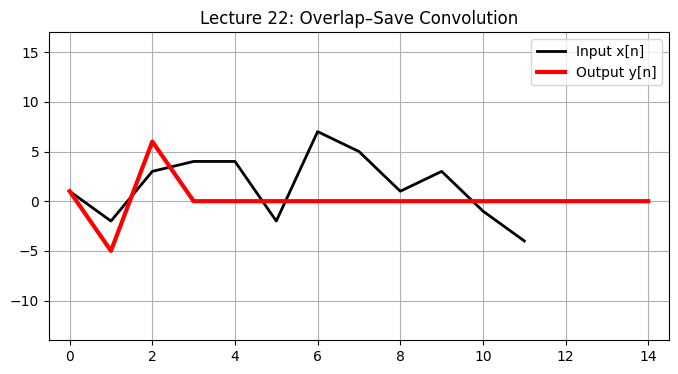

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 22: Overlap–Save Method
# -----------------------------

# Input signal
x = np.array([1, -2, 3, 4, 4, -2, 7, 5, 1, 3, -1, -4])
N = len(x)

# FIR filter
h = np.array([1, -3, -3, 1])
M = len(h)

# Block parameters
L = 6                  # block length
overlap = M - 1        # overlap for overlap–save
step = L - overlap

# Pad input at beginning
x_pad = np.concatenate([np.zeros(overlap), x])

# Prepare blocks
blocks = []
for i in range(0, len(x_pad) - L + 1, step):
    blocks.append(x_pad[i:i+L])

# Circular convolution of each block
conv_blocks = []
for b in blocks:
    conv = np.convolve(b, h, mode='full')[:L]
    conv_blocks.append(conv)

# Output buffer
y_len = N + M - 1
y = np.zeros(y_len)

# Plot setup
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(-0.5, y_len - 0.5)
ax.set_ylim(min(x) - 10, max(x) + 10)
ax.grid(True)
ax.set_title("Lecture 22: Overlap–Save Convolution")

# Static input
ax.plot(np.arange(N), x, 'k', lw=2, label="Input x[n]")

# Animated output
y_line, = ax.plot([], [], 'r', lw=3, label="Output y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture‑9 style)
# -----------------------------
def update(frame):
    y_partial = np.zeros_like(y)

    for i in range(frame + 1):
        start = i * step
        # discard the first (M-1) corrupted samples
        valid = conv_blocks[i][overlap:]
        y_partial[start:start+len(valid)] = valid

    y_line.set_data(np.arange(len(y)), y_partial)
    return (y_line,)

anim = FuncAnimation(
    fig,
    update,
    frames=len(conv_blocks),
    interval=900
)

HTML(anim.to_jshtml())